In [1]:
import pandas as pd

# Path to your Excel file
file_path = r"C:\Users\sjs93\OneDrive\Desktop\3chamber_SP_ECG_cohort1.xlsx"

# Load sheets into separate DataFrames
df_baseline = pd.read_excel(file_path, sheet_name="BL")
df_social = pd.read_excel(file_path, sheet_name="Social Preference")

# Quick look
print("Baseline data preview:")
print(df_baseline.head())

print("\nSocial Preference data preview:")
print(df_social.head())


Baseline data preview:
   Test  Animal  Left ROI : time investigating (s)  \
0    89     1.2                               87.6   
1    90     3.5                               58.2   
2    91     3.6                               55.4   
3    92     4.7                               39.2   
4    93     4.8                               45.3   

   Right ROI : time investigating (s)  Whole-Chamber : time (s)  \
0                               131.5                       300   
1                               173.7                       300   
2                                53.6                       300   
3                               118.4                       300   
4                                87.2                       300   

   Whole Chamber left : time (s)  Whole Chamber right : time (s) Sex RB side   
0                          168.7                            84.5   M     left  
1                          102.9                           183.5   M    right  
2        

Notebook Entry: Baseline Side Bias Calculation and Normalization of Social Preference Data

In order to control for innate side preferences during the social choice test, we first calculated a baseline side bias index for each mouse using the baseline recording data. The side bias index was computed as:

Side Bias Index
=
Time on Left Side
−
Time on Right Side/
Time on Left Side
+
Time on Right Side

​
 
Values near +1 indicate strong preference for the left side, near -1 indicate strong preference for the right side, and values near 0 indicate no side bias.

No animals exceeded the threshold for extreme bias (absolute value > 0.8), so all were retained for further analysis.

Next, to account for baseline side biases when analyzing social preference behavior, we normalized the investigation times during the social preference test by each animal’s corresponding baseline side time. Specifically, time investigating the Juvenile stimulus was divided by the baseline time spent on that stimulus’s side, and similarly for the Retired Breeder stimulus.

This normalization procedure adjusts for natural side biases, allowing for a more accurate assessment of true social preferences. The normalized data will be used in subsequent statistical analyses and plotting to compare investigation times toward Juvenile and Retired Breeder stimuli.

In [2]:
df_baseline

,Test,Animal,Left ROI : time investigating (s),Right ROI : time investigating (s),Whole-Chamber : time (s),Whole Chamber left : time (s),Whole Chamber right : time (s),Sex,RB side
0,89,1.20,87.6,131.5,300,168.7,84.5,M,left
1,90,3.50,58.2,173.7,300,102.9,183.5,M,right
2,91,3.60,55.4,53.6,300,108.5,96.6,M,left
3,92,4.70,39.2,118.4,300,67.1,180.7,M,right
4,93,4.80,45.3,87.2,300,87.8,126.0,M,left
5,89,2.30,43.1,87.7,300,71.7,151.7,M,left
6,90,2.40,16.0,8.4,300,47.9,18.6,M,right
7,91,5.13,89.0,49.2,300,129.0,87.8,M,right
8,92,1.10,105.1,42.8,300,157.5,83.6,M,right


In [3]:
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # teal-ish (RI1)
    'Negative': (169/255, 83/255, 118/255)   # magenta-ish (RI2)
}

In [4]:
import numpy as np

# Assuming these are your relevant columns — update if different:
# For Baseline (BL) tab:
left_col_baseline = "Whole Chamber left : time (s)"
right_col_baseline = "Whole Chamber right : time (s)"

# For Social Preference tab:
left_col_social = "Juvenile WC : time (s)"
right_col_social = "Retired breeder WC : time (s)"

# Calculate baseline side bias index per animal
df_baseline["Side_Bias_Index"] = (
    df_baseline[left_col_baseline] - df_baseline[right_col_baseline]
) / (df_baseline[left_col_baseline] + df_baseline[right_col_baseline])

# Flag animals with extreme bias (absolute bias > 0.8)
bias_threshold = 0.8
df_baseline["Extreme_Bias"] = df_baseline["Side_Bias_Index"].abs() > bias_threshold

print("Animals with extreme baseline side bias:")
print(df_baseline.loc[df_baseline["Extreme_Bias"], ["Animal", "Side_Bias_Index"]])

# Merge baseline bias info into social preference data
df_social = df_social.merge(
    df_baseline[["Animal", "Side_Bias_Index", "Extreme_Bias"]],
    on="Animal",
    how="left"
)

# Normalize social preference times by baseline times per side
df_social["Norm_Juvenile_Time"] = df_social[left_col_social] / df_baseline.set_index("Animal").loc[df_social["Animal"], left_col_baseline].values
df_social["Norm_RB_Time"] = df_social[right_col_social] / df_baseline.set_index("Animal").loc[df_social["Animal"], right_col_baseline].values

print("\nNormalized social preference times (first few rows):")
print(df_social[["Animal", "Norm_Juvenile_Time", "Norm_RB_Time"]].head())


Animals with extreme baseline side bias:
Empty DataFrame
Columns: [Animal, Side_Bias_Index]
Index: []

Normalized social preference times (first few rows):
   Animal  Norm_Juvenile_Time  Norm_RB_Time
0     1.2            1.320095      0.347929
1     3.5            1.008746      1.048501
2     3.6            1.543779      1.232919
3     4.7            2.031297      0.841173
4     4.8            2.449886      0.506349


In [5]:
df_social

,Test,Animal,Juvenile ROI : time investigating (s),Retired breeder ROI : time investigating (s),Whole-Chamber : time (s),Juvenile WC : time (s),Retired breeder WC : time (s),Sex,RB side,Side_Bias_Index,Extreme_Bias,Norm_Juvenile_Time,Norm_RB_Time
0,94,1.20,191.3,3.4,300,222.7,29.4,M,left,0.332543,False,1.320095,0.347929
1,95,3.50,90.5,192.2,300,103.8,192.4,M,right,-0.281425,False,1.008746,1.048501
2,97,3.60,132.7,82.3,300,167.5,119.1,M,left,0.058020,False,1.543779,1.232919
3,98,4.70,104.9,140.7,300,136.3,152.0,M,right,-0.458434,False,2.031297,0.841173
4,96,4.80,149.7,53.6,300,215.1,63.8,M,left,-0.178672,False,2.449886,0.506349
5,100,2.30,149.7,87.5,300,182.9,96.5,M,left,-0.358102,False,2.550907,0.636124
6,101,2.40,54.5,74.7,300,83.2,105.2,M,right,0.440602,False,1.736952,5.655914
7,102,5.13,50.2,154.7,300,102.3,174.6,M,right,0.190037,False,0.793023,1.988610
8,99,1.10,239.6,2.7,300,274.8,4.0,M,right,0.306512,False,1.744762,0.047847


In [6]:
print(f"Total animals in baseline data: {df_baseline['Animal'].nunique()}")
print(f"Total animals in social preference data: {df_social['Animal'].nunique()}")
print(f"Total rows in social data: {len(df_social)}")


Total animals in baseline data: 9
Total animals in social preference data: 9
Total rows in social data: 9


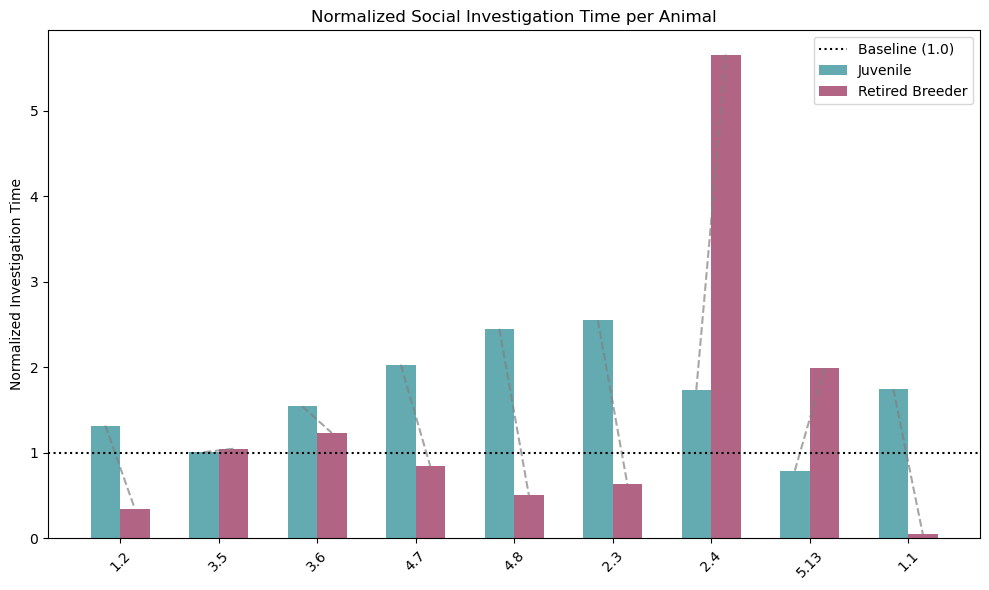

In [7]:
import matplotlib.pyplot as plt
import numpy as np

animals = df_social["Animal"].astype(str)
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors from your palette
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

plt.figure(figsize=(10,6))

# Bars for each animal (normalized times)
plt.bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
plt.bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Lines connecting pairs for each animal
for i in range(len(animals)):
    plt.plot([x[i] - 0.15, x[i] + 0.15],
             [norm_juv.iloc[i], norm_rb.iloc[i]],
             color='gray', linestyle='--', alpha=0.7)

# Formatting
plt.xticks(x, animals, rotation=45)
plt.ylabel("Normalized Investigation Time")
plt.title("Normalized Social Investigation Time per Animal")
plt.axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")  
plt.legend()
plt.tight_layout()
plt.show()


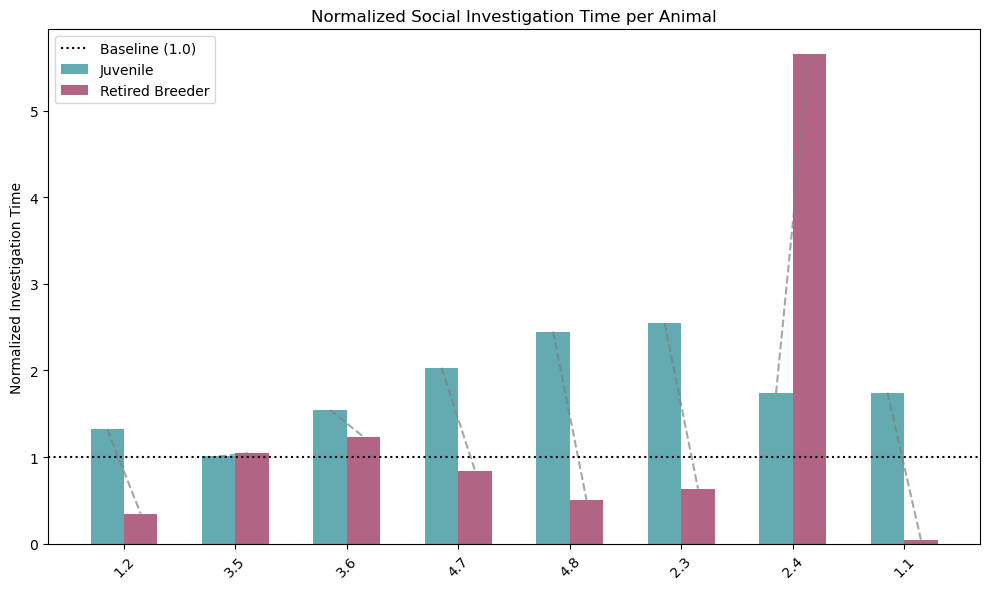

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- Exclude subject 5.13 ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors from your palette
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

plt.figure(figsize=(10,6))

# Bars for each animal (normalized times)
plt.bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
plt.bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Lines connecting pairs for each animal
for i in range(len(animals)):
    plt.plot([x[i] - 0.15, x[i] + 0.15],
             [norm_juv.iloc[i], norm_rb.iloc[i]],
             color='gray', linestyle='--', alpha=0.7)

# Formatting
plt.xticks(x, animals, rotation=45)
plt.ylabel("Normalized Investigation Time")
plt.title("Normalized Social Investigation Time per Animal")
plt.axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")  
plt.legend()
plt.tight_layout()
plt.show()


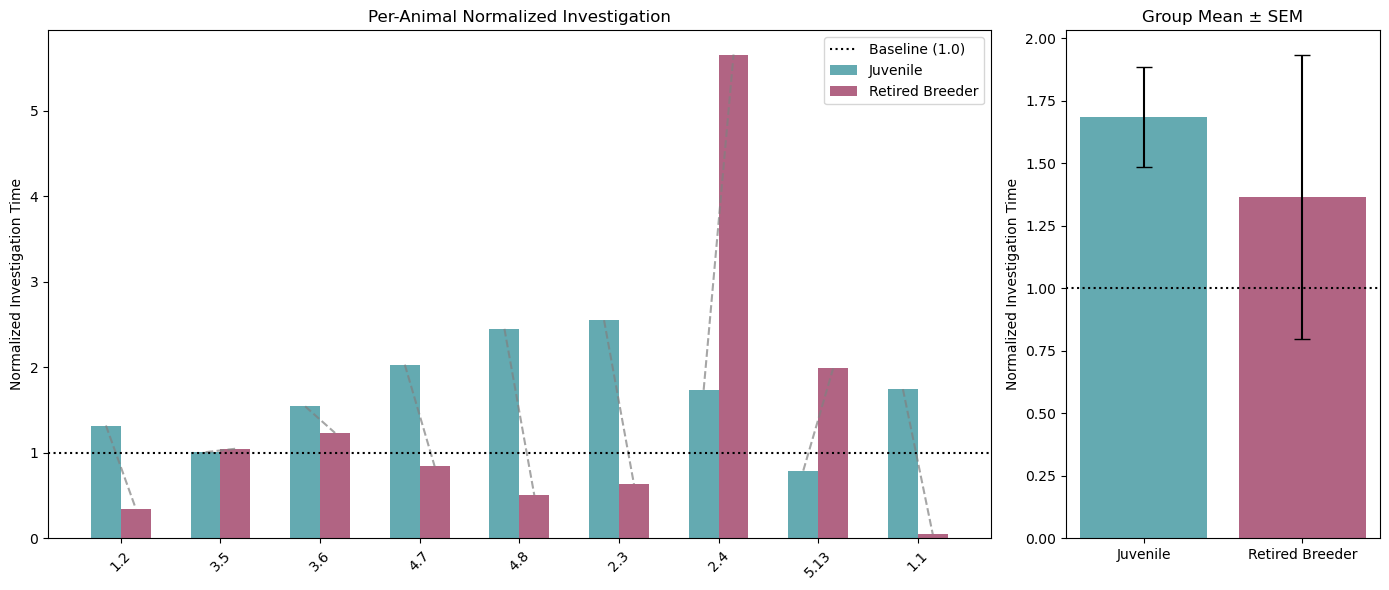

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem  # for SEM

animals = df_social["Animal"].astype(str)
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

fig, axes = plt.subplots(1, 2, figsize=(14,6), gridspec_kw={'width_ratios':[3,1]})

# ---- (A) Per-animal normalized investigation ----
axes[0].bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Connectors
for i in range(len(animals)):
    axes[0].plot([x[i] - 0.15, x[i] + 0.15],
                 [norm_juv.iloc[i], norm_rb.iloc[i]],
                 color='gray', linestyle='--', alpha=0.7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45)
axes[0].set_ylabel("Normalized Investigation Time")
axes[0].set_title("Per-Animal Normalized Investigation")
axes[0].axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")
axes[0].legend()

# ---- (B) Group mean ± SEM ----
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(["Juvenile", "Retired Breeder"], means,
            yerr=errors, capsize=6,
            color=[pos_color, neg_color], alpha=0.9)

axes[1].axhline(1, color='black', linestyle='dotted')
axes[1].set_ylabel("Normalized Investigation Time")
axes[1].set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()


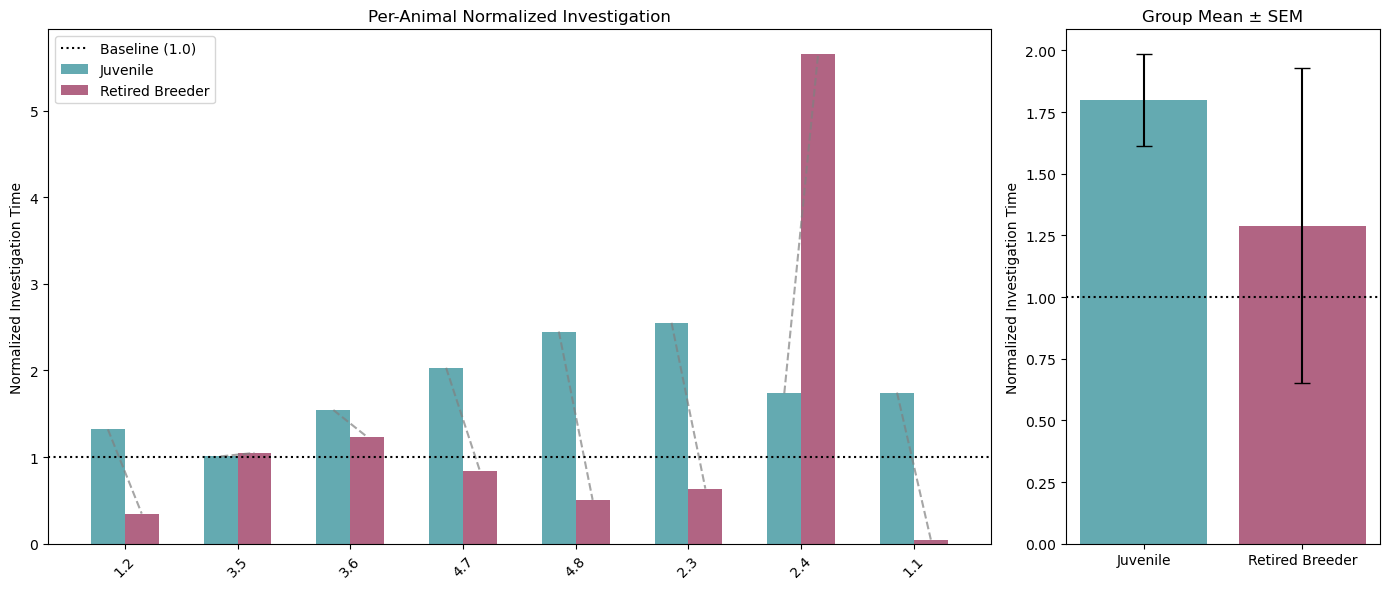

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem  # for SEM

# --- Exclude subject 5.13 ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

fig, axes = plt.subplots(1, 2, figsize=(14,6), gridspec_kw={'width_ratios':[3,1]})

# ---- (A) Per-animal normalized investigation ----
axes[0].bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Connectors
for i in range(len(animals)):
    axes[0].plot([x[i] - 0.15, x[i] + 0.15],
                 [norm_juv.iloc[i], norm_rb.iloc[i]],
                 color='gray', linestyle='--', alpha=0.7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45)
axes[0].set_ylabel("Normalized Investigation Time")
axes[0].set_title("Per-Animal Normalized Investigation")
axes[0].axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")
axes[0].legend()

# ---- (B) Group mean ± SEM ----
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(["Juvenile", "Retired Breeder"], means,
            yerr=errors, capsize=6,
            color=[pos_color, neg_color], alpha=0.9)

axes[1].axhline(1, color='black', linestyle='dotted')
axes[1].set_ylabel("Normalized Investigation Time")
axes[1].set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()


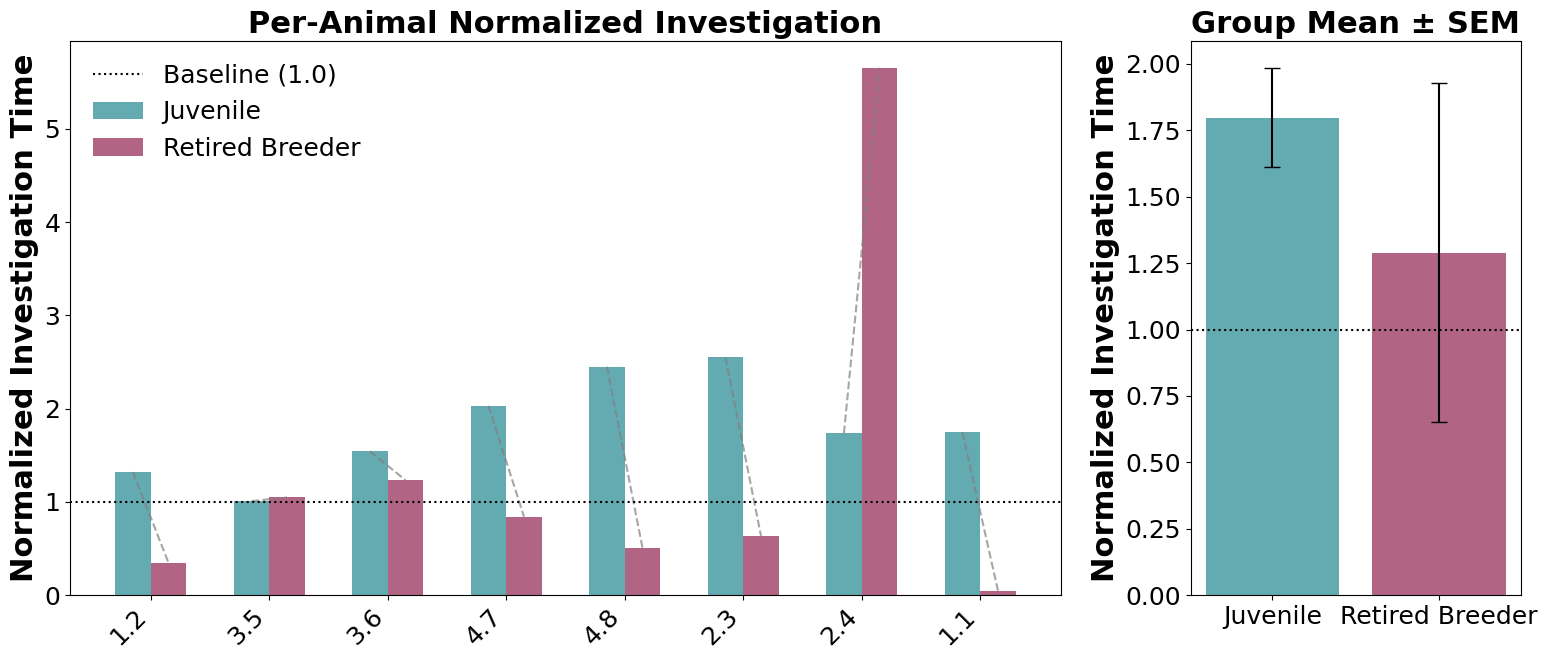

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem  # for SEM

# --- Exclude subject 5.13 ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

# --- Set global font sizes ---
plt.rcParams.update({
    "font.size": 20,       # default text
    "axes.titlesize": 26,  # subplot titles
    "axes.labelsize": 22,  # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios':[3,1]})

# ---- (A) Per-animal normalized investigation ----
axes[0].bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Connectors
for i in range(len(animals)):
    axes[0].plot([x[i] - 0.15, x[i] + 0.15],
                 [norm_juv.iloc[i], norm_rb.iloc[i]],
                 color='gray', linestyle='--', alpha=0.7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45, ha='right')
axes[0].set_ylabel("Normalized Investigation Time", fontsize=22, weight='bold')
axes[0].set_title("Per-Animal Normalized Investigation", fontsize=22, weight='bold')
axes[0].axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")
axes[0].legend(frameon=False)

# ---- (B) Group mean ± SEM ----
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(["Juvenile", "Retired Breeder"], means,
            yerr=errors, capsize=6,
            color=[pos_color, neg_color], alpha=0.9)

axes[1].axhline(1, color='black', linestyle='dotted')
axes[1].set_ylabel("Normalized Investigation Time", fontsize=22, weight='bold')
axes[1].set_title("Group Mean ± SEM", fontsize=22, weight='bold')

plt.tight_layout()
plt.show()


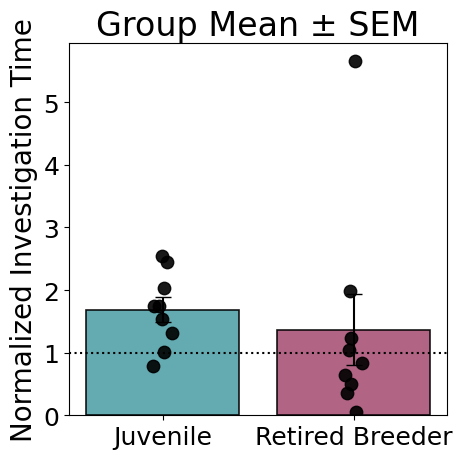

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# --- Prepare data ---
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

# --- Colors ---
pos_color = custom_palette['Positive']   # Juvenile bar
neg_color = custom_palette['Negative']   # Retired Breeder bar

# --- Compute means and SEM ---
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

# --- Plot settings ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, ax = plt.subplots(figsize=(5, 5))

# --- Bar plot ---
x = np.arange(2)
ax.bar(x, means, yerr=errors, capsize=6,
       color=[pos_color, neg_color], alpha=0.9,
       edgecolor='black', linewidth=1.2)

# --- Add black individual data points ---
ax.scatter(np.repeat(x[0], len(norm_juv)) + np.random.uniform(-0.05, 0.05, len(norm_juv)),
           norm_juv, color='black', s=80, alpha=0.9, zorder=3)

ax.scatter(np.repeat(x[1], len(norm_rb)) + np.random.uniform(-0.05, 0.05, len(norm_rb)),
           norm_rb, color='black', s=80, alpha=0.9, zorder=3)

# --- Aesthetics ---
ax.axhline(1, color='black', linestyle='dotted', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")
ax.set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()


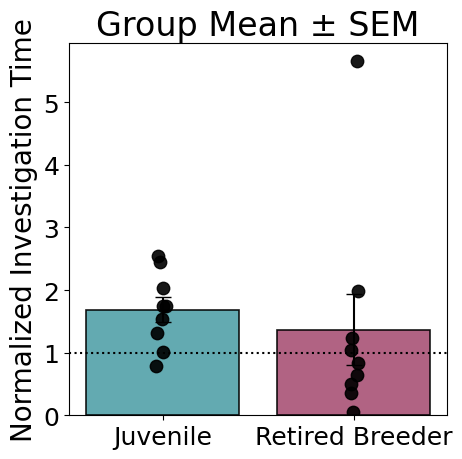

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# --- Prepare data ---
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

# --- Colors ---
pos_color = custom_palette['Positive']   # Juvenile bar
neg_color = custom_palette['Negative']   # Retired Breeder bar

# --- Compute means and SEM ---
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

# --- Plot settings ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, ax = plt.subplots(figsize=(5, 5))

# --- Transparent background ---
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# --- Bar plot ---
x = np.arange(2)
ax.bar(x, means, yerr=errors, capsize=6,
       color=[pos_color, neg_color], alpha=0.9,
       edgecolor='black', linewidth=1.2)

# --- Add black individual data points ---
ax.scatter(np.repeat(x[0], len(norm_juv)) + np.random.uniform(-0.05, 0.05, len(norm_juv)),
           norm_juv, color='black', s=80, alpha=0.9, zorder=3)

ax.scatter(np.repeat(x[1], len(norm_rb)) + np.random.uniform(-0.05, 0.05, len(norm_rb)),
           norm_rb, color='black', s=80, alpha=0.9, zorder=3)

# --- Aesthetics ---
ax.axhline(1, color='black', linestyle='dotted', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")
ax.set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()


In [14]:
# --- Define rank mapping ---
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

# --- Clean up Animal column (convert 1.2 → 1_2 etc.) ---
df_social = df_social.copy()
df_social["Animal"] = df_social["Animal"].astype(str).str.replace(".", "_", regex=False)

# --- Add Rank column ---
df_social["Rank"] = df_social["Animal"].map(rank_fix)

# --- Exclude subject 5.13 (now formatted 5_13) ---
df_social = df_social[df_social["Animal"] != "5_13"]

# --- Check mapping ---
print(df_social[["Animal", "Rank"]])




  Animal         Rank
0    1_2     Dominant
1    3_5  Subordinate
2    3_6     Dominant
3    4_7  Subordinate
4    4_8     Dominant
5    2_3  Subordinate
6    2_4     Dominant
8    1_1  Subordinate


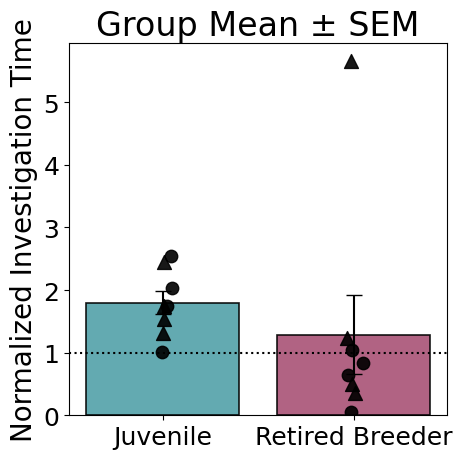

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# --- Split by rank ---
dom = df_social[df_social["Rank"] == "Dominant"]
sub = df_social[df_social["Rank"] == "Subordinate"]

# --- Colors ---
pos_color = custom_palette['Positive']   # Juvenile bar
neg_color = custom_palette['Negative']   # Retired Breeder bar

# --- Compute group means and SEM ---
means = [df_social["Norm_Juvenile_Time"].mean(),
         df_social["Norm_RB_Time"].mean()]
errors = [sem(df_social["Norm_Juvenile_Time"]),
          sem(df_social["Norm_RB_Time"])]

# --- Plot settings ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

fig, ax = plt.subplots(figsize=(5, 5))

# --- Transparent background ---
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# --- Bar plot ---
x = np.arange(2)
ax.bar(x, means, yerr=errors, capsize=6,
       color=[pos_color, neg_color], alpha=0.9,
       edgecolor='black', linewidth=1.2)

# --- Add data points by rank ---
# Subordinates (black circles)
ax.scatter(np.repeat(x[0], len(sub)) + np.random.uniform(-0.05, 0.05, len(sub)),
           sub["Norm_Juvenile_Time"], color='black', s=80, alpha=0.9, zorder=3, marker='o')
ax.scatter(np.repeat(x[1], len(sub)) + np.random.uniform(-0.05, 0.05, len(sub)),
           sub["Norm_RB_Time"], color='black', s=80, alpha=0.9, zorder=3, marker='o')

# Dominants (black triangles)
ax.scatter(np.repeat(x[0], len(dom)) + np.random.uniform(-0.05, 0.05, len(dom)),
           dom["Norm_Juvenile_Time"], color='black', s=100, alpha=0.9, zorder=3, marker='^')
ax.scatter(np.repeat(x[1], len(dom)) + np.random.uniform(-0.05, 0.05, len(dom)),
           dom["Norm_RB_Time"], color='black', s=100, alpha=0.9, zorder=3, marker='^')

# --- Aesthetics ---
ax.axhline(1, color='black', linestyle='dotted', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")
ax.set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()



In [16]:
def remove_outliers_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series[(series >= lower) & (series <= upper)]


In [17]:
df_clean = df_social.copy()

df_clean["Norm_Juvenile_Time"] = remove_outliers_iqr(
    df_clean["Norm_Juvenile_Time"]
)
df_clean["Norm_RB_Time"] = remove_outliers_iqr(
    df_clean["Norm_RB_Time"]
)

# drop rows where values were removed
df_clean = df_clean.dropna(
    subset=["Norm_Juvenile_Time", "Norm_RB_Time"]
)


In [18]:
dom = df_clean[df_clean["Rank"] == "Dominant"]
sub = df_clean[df_clean["Rank"] == "Subordinate"]

means = [
    df_clean["Norm_Juvenile_Time"].mean(),
    df_clean["Norm_RB_Time"].mean()
]

errors = [
    sem(df_clean["Norm_Juvenile_Time"]),
    sem(df_clean["Norm_RB_Time"])
]


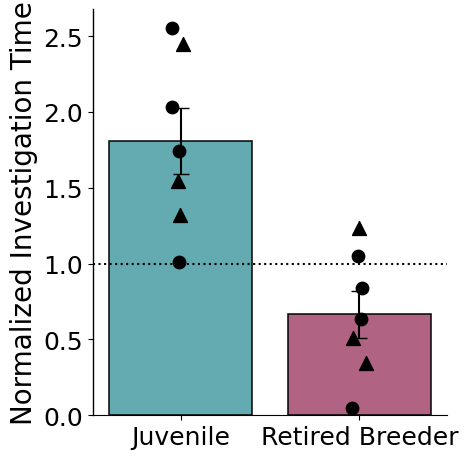

In [25]:
fig, ax = plt.subplots(figsize=(5, 5))

# transparent background
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

x = np.arange(2)

# bars
ax.bar(
    x, means, yerr=errors, capsize=6,
    color=[pos_color, neg_color], alpha=0.9,
    edgecolor="black", linewidth=1.2
)

# Subordinates (circles)
ax.scatter(
    np.repeat(x[0], len(sub)) + np.random.uniform(-0.05, 0.05, len(sub)),
    sub["Norm_Juvenile_Time"],
    color="black", s=80, zorder=3, marker="o"
)
ax.scatter(
    np.repeat(x[1], len(sub)) + np.random.uniform(-0.05, 0.05, len(sub)),
    sub["Norm_RB_Time"],
    color="black", s=80, zorder=3, marker="o"
)

# Dominants (triangles)
ax.scatter(
    np.repeat(x[0], len(dom)) + np.random.uniform(-0.05, 0.05, len(dom)),
    dom["Norm_Juvenile_Time"],
    color="black", s=100, zorder=3, marker="^"
)
ax.scatter(
    np.repeat(x[1], len(dom)) + np.random.uniform(-0.05, 0.05, len(dom)),
    dom["Norm_RB_Time"],
    color="black", s=100, zorder=3, marker="^"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)

# aesthetics
ax.axhline(1, color="black", linestyle="dotted", linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")

# remove title (intentionally blank)
ax.set_title("")

plt.tight_layout()
plt.show()


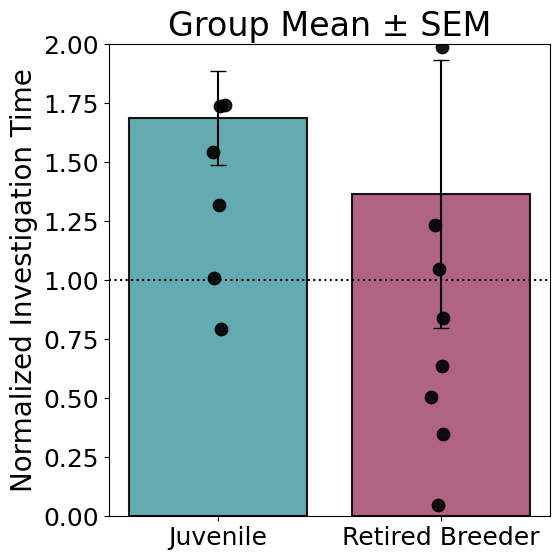

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# --- Prepare data ---
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

# --- Colors ---
pos_color = custom_palette['Positive']   # Juvenile bar
neg_color = custom_palette['Negative']   # Retired Breeder bar

# --- Compute means and SEM ---
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

# --- Plot settings ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# Bars and points (same code as before)
ax.bar(x, means, yerr=errors, capsize=6,
       color=[pos_color, neg_color], alpha=0.9,
       edgecolor='black', linewidth=1.5)

ax.scatter(np.repeat(x[0], len(norm_juv)) + np.random.uniform(-0.05, 0.05, len(norm_juv)),
           norm_juv, color='black', s=80, alpha=0.9, zorder=3)
ax.scatter(np.repeat(x[1], len(norm_rb)) + np.random.uniform(-0.05, 0.05, len(norm_rb)),
           norm_rb, color='black', s=80, alpha=0.9, zorder=3)

# Axis tweaks
ax.axhline(1, color='black', linestyle='dotted', linewidth=1.5)
ax.set_ylim(0, 2)   # instead of (-0.5, None)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")
ax.set_title("Group Mean ± SEM")

plt.tight_layout()
plt.show()

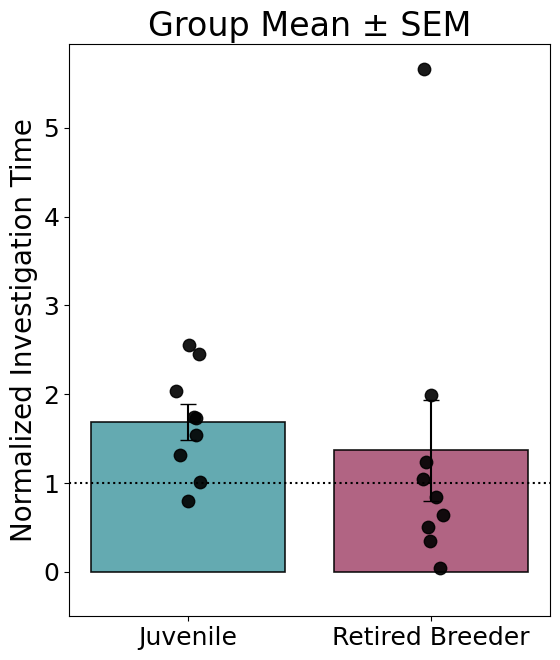

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# --- Prepare data ---
norm_juv = df_social["Norm_Juvenile_Time"]
norm_rb = df_social["Norm_RB_Time"]

# --- Colors ---
pos_color = custom_palette['Positive']   # Juvenile bar
neg_color = custom_palette['Negative']   # Retired Breeder bar

# --- Compute means and SEM ---
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

# --- Plot settings ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, ax = plt.subplots(figsize=(6, 7))

# --- Bar plot ---
x = np.arange(2)
ax.bar(x, means, yerr=errors, capsize=6,
       color=[pos_color, neg_color], alpha=0.9,
       edgecolor='black', linewidth=1.2)

# --- Add black individual data points ---
ax.scatter(np.repeat(x[0], len(norm_juv)) + np.random.uniform(-0.05, 0.05, len(norm_juv)),
           norm_juv, color='black', s=80, alpha=0.9, zorder=3)

ax.scatter(np.repeat(x[1], len(norm_rb)) + np.random.uniform(-0.05, 0.05, len(norm_rb)),
           norm_rb, color='black', s=80, alpha=0.9, zorder=3)

# --- Aesthetics ---
ax.axhline(1, color='black', linestyle='dotted', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(["Juvenile", "Retired Breeder"])
ax.set_ylabel("Normalized Investigation Time")
ax.set_title("Group Mean ± SEM")
ax.set_ylim(-0.5, None)   # 👈 sets the bottom of the y-axis to -0.5

plt.tight_layout()
plt.show()


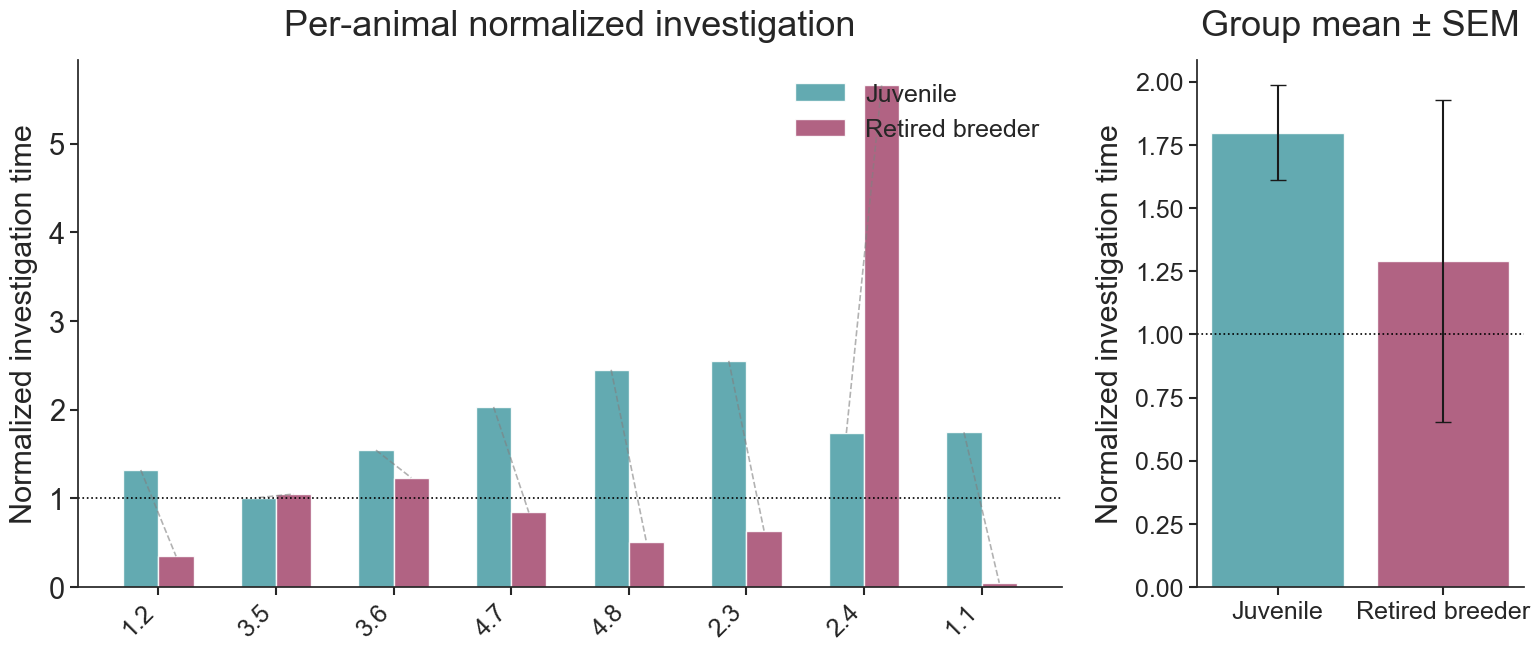

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem  # for SEM

# --- Prepare data ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# --- Define colors (Padilla palette) ---
pos_color = custom_palette["Positive"]   # Juvenile (teal)
neg_color = custom_palette["Negative"]   # Retired Breeder (magenta)

# --- Poster font and transparent style ---
sns.set(style="ticks", font_scale=1.9)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_alpha(0.0)
for ax in axes:
    ax.set_facecolor("none")

# ======================================================
# (A) Per-animal normalized investigation
# ======================================================
axes[0].bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, label="Retired breeder", color=neg_color, alpha=0.9)

# Connect paired subjects
for i in range(len(animals)):
    axes[0].plot(
        [x[i] - 0.15, x[i] + 0.15],
        [norm_juv.iloc[i], norm_rb.iloc[i]],
        color="gray", linestyle="--", alpha=0.6, linewidth=1.2
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45, ha="right", fontsize=18)
axes[0].set_ylabel("Normalized investigation time", fontsize=22, labelpad=8)
axes[0].axhline(1, color="black", linestyle="dotted", linewidth=1.2)
axes[0].set_title("Per-animal normalized investigation", fontsize=26, pad=18)
axes[0].legend(frameon=False, fontsize=18, loc="upper right")

# ======================================================
# (B) Group mean ± SEM
# ======================================================
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(
    ["Juvenile", "Retired breeder"], means,
    yerr=errors, capsize=6,
    color=[pos_color, neg_color], alpha=0.9
)
axes[1].axhline(1, color="black", linestyle="dotted", linewidth=1.2)
axes[1].set_ylabel("Normalized investigation time", fontsize=22, labelpad=8)
axes[1].set_title("Group mean ± SEM", fontsize=26, pad=18)
axes[1].tick_params(axis="x", labelsize=18)
axes[1].tick_params(axis="y", labelsize=18)

# --- Shared cleanup ---
for ax in axes:
    sns.despine(ax=ax)
    ax.tick_params(width=1.5, length=6)

plt.tight_layout()
plt.show()


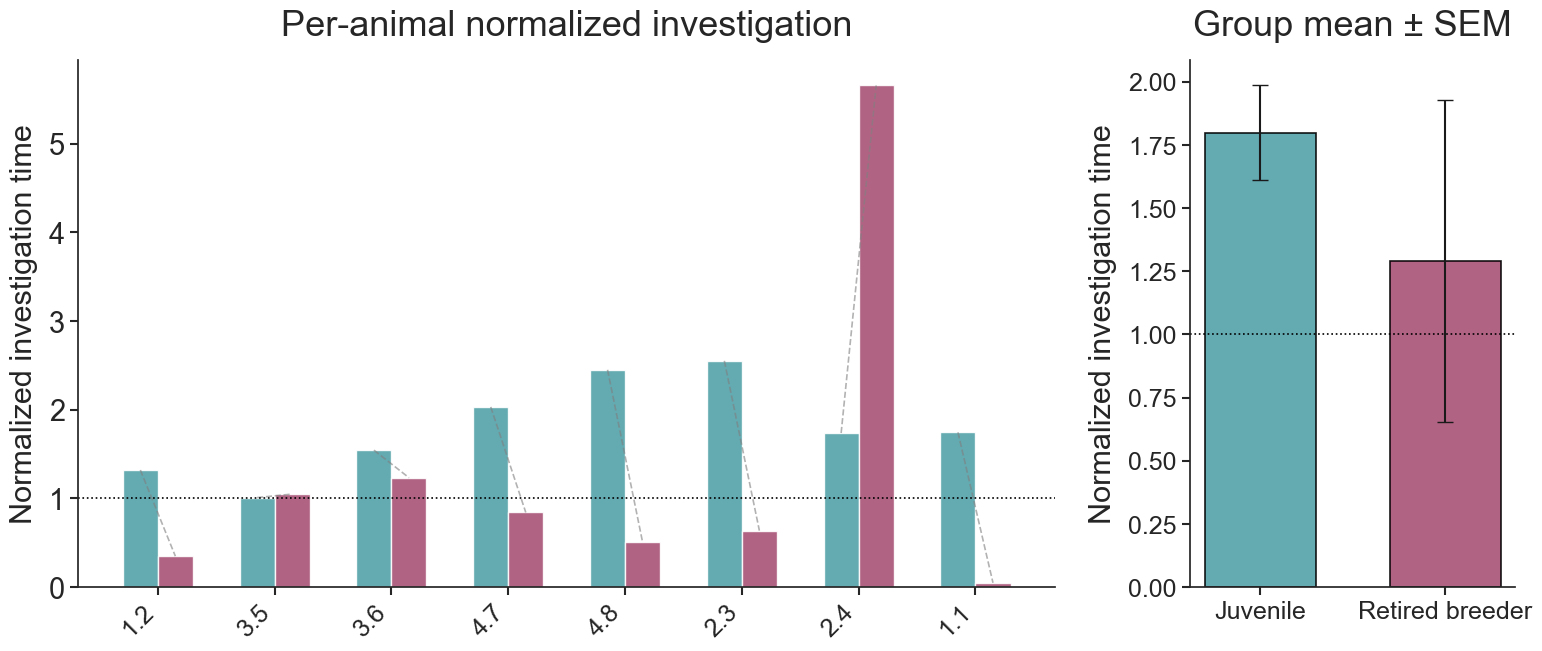

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem  # for SEM

# --- Prepare data ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# --- Colors (Padilla palette) ---
pos_color = custom_palette["Positive"]   # Juvenile (teal)
neg_color = custom_palette["Negative"]   # Retired Breeder (magenta)

# --- Poster-style setup ---
sns.set(style="ticks", font_scale=1.9)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_alpha(0.0)
for ax in axes:
    ax.set_facecolor("none")

# ======================================================
# (A) Per-animal normalized investigation
# ======================================================
axes[0].bar(x - 0.15, norm_juv, width=0.3, color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, color=neg_color, alpha=0.9)

# Connect paired subjects
for i in range(len(animals)):
    axes[0].plot(
        [x[i] - 0.15, x[i] + 0.15],
        [norm_juv.iloc[i], norm_rb.iloc[i]],
        color="gray", linestyle="--", alpha=0.6, linewidth=1.2
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45, ha="right", fontsize=18)
axes[0].set_ylabel("Normalized investigation time", fontsize=22, labelpad=8)
axes[0].axhline(1, color="black", linestyle="dotted", linewidth=1.2)
axes[0].set_title("Per-animal normalized investigation", fontsize=26, pad=18)

# ======================================================
# (B) Group mean ± SEM
# ======================================================
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(
    ["Juvenile", "Retired breeder"],
    means, yerr=errors,
    capsize=6, width=0.6,
    color=[pos_color, neg_color],
    alpha=0.9, edgecolor="black", linewidth=1.2
)
axes[1].axhline(1, color="black", linestyle="dotted", linewidth=1.2)
axes[1].set_ylabel("Normalized investigation time", fontsize=22, labelpad=8)
axes[1].set_title("Group mean ± SEM", fontsize=26, pad=18)
axes[1].tick_params(axis="x", labelsize=18)
axes[1].tick_params(axis="y", labelsize=18)

# ======================================================
# Shared clean-up
# ======================================================
for ax in axes:
    sns.despine(ax=ax)
    ax.tick_params(width=1.5, length=6)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()



In [41]:
import pandas as pd
from scipy.stats import ttest_1samp, wilcoxon, ttest_rel

# --- Extract data ---
juv = norm_juv.values
rb = norm_rb.values

results = []

# ---- One-sample tests against baseline = 1 ----
for label, data in [("Juvenile", juv), ("Retired Breeder", rb)]:
    # t-test
    t_stat, t_p = ttest_1samp(data, 1.0)
    # Wilcoxon (against baseline = 1)
    try:
        w_stat, w_p = wilcoxon(data - 1.0)
    except ValueError:  # in case all diffs = 0
        w_stat, w_p = (None, None)
    
    results.append({
        "Comparison": f"{label} vs Baseline=1",
        "Test": "One-sample t-test", "Statistic": t_stat, "p-value": t_p, "n": len(data)
    })
    results.append({
        "Comparison": f"{label} vs Baseline=1",
        "Test": "Wilcoxon signed-rank", "Statistic": w_stat, "p-value": w_p, "n": len(data)
    })

# ---- Paired Juvenile vs Retired Breeder ----
# t-test
t_stat, t_p = ttest_rel(juv, rb)
# Wilcoxon
w_stat, w_p = wilcoxon(juv, rb)

results.append({
    "Comparison": "Juvenile vs Retired Breeder",
    "Test": "Paired t-test", "Statistic": t_stat, "p-value": t_p, "n": len(juv)
})
results.append({
    "Comparison": "Juvenile vs Retired Breeder",
    "Test": "Wilcoxon signed-rank", "Statistic": w_stat, "p-value": w_p, "n": len(juv)
})

# --- Format into DataFrame ---
results_df = pd.DataFrame(results)
print("✅ Statistical Results:")
print(results_df)


✅ Statistical Results:
                      Comparison                  Test  Statistic   p-value  n
0         Juvenile vs Baseline=1     One-sample t-test   3.440768  0.008814  9
1         Juvenile vs Baseline=1  Wilcoxon signed-rank   2.000000  0.011719  9
2  Retired Breeder vs Baseline=1     One-sample t-test   0.646566  0.536018  9
3  Retired Breeder vs Baseline=1  Wilcoxon signed-rank  21.000000  0.910156  9
4    Juvenile vs Retired Breeder         Paired t-test   0.506219  0.626355  9
5    Juvenile vs Retired Breeder  Wilcoxon signed-rank  15.000000  0.425781  9


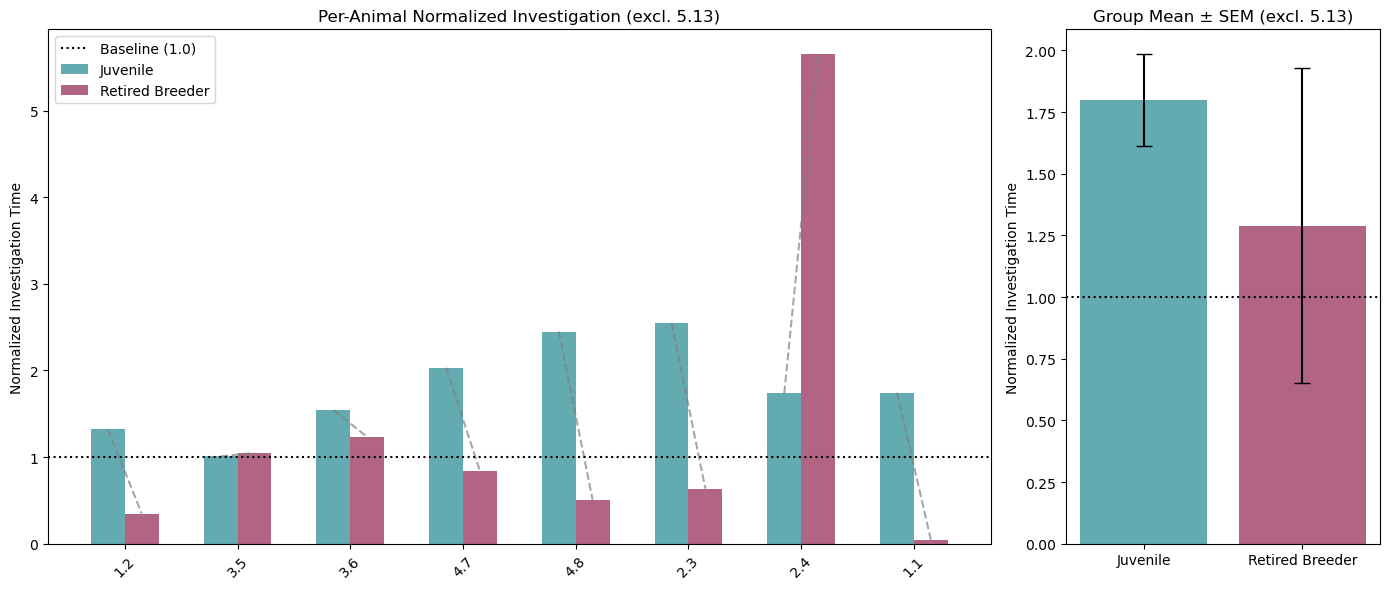

✅ Statistical Results (excl. 5.13):
                      Comparison                  Test  Statistic   p-value  n
0         Juvenile vs Baseline=1     One-sample t-test   4.257610  0.003758  8
1         Juvenile vs Baseline=1  Wilcoxon signed-rank   0.000000  0.007812  8
2  Retired Breeder vs Baseline=1     One-sample t-test   0.453891  0.663645  8
3  Retired Breeder vs Baseline=1  Wilcoxon signed-rank  12.000000  0.460938  8
4    Juvenile vs Retired Breeder         Paired t-test   0.745563  0.480212  8
5    Juvenile vs Retired Breeder  Wilcoxon signed-rank   9.000000  0.250000  8


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem, ttest_1samp, ttest_rel, wilcoxon

# --- Exclude subject 5.13 ---
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
norm_juv = df_plot["Norm_Juvenile_Time"]
norm_rb = df_plot["Norm_RB_Time"]

x = np.arange(len(animals))

# Define colors
pos_color = custom_palette['Positive']   # Juvenile
neg_color = custom_palette['Negative']   # Retired Breeder

fig, axes = plt.subplots(1, 2, figsize=(14,6), gridspec_kw={'width_ratios':[3,1]})

# ---- (A) Per-animal normalized investigation ----
axes[0].bar(x - 0.15, norm_juv, width=0.3, label="Juvenile", color=pos_color, alpha=0.9)
axes[0].bar(x + 0.15, norm_rb, width=0.3, label="Retired Breeder", color=neg_color, alpha=0.9)

# Connectors
for i in range(len(animals)):
    axes[0].plot([x[i] - 0.15, x[i] + 0.15],
                 [norm_juv.iloc[i], norm_rb.iloc[i]],
                 color='gray', linestyle='--', alpha=0.7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(animals, rotation=45)
axes[0].set_ylabel("Normalized Investigation Time")
axes[0].set_title("Per-Animal Normalized Investigation (excl. 5.13)")
axes[0].axhline(1, color='black', linestyle='dotted', label="Baseline (1.0)")
axes[0].legend()

# ---- (B) Group mean ± SEM ----
means = [norm_juv.mean(), norm_rb.mean()]
errors = [sem(norm_juv), sem(norm_rb)]

axes[1].bar(["Juvenile", "Retired Breeder"], means,
            yerr=errors, capsize=6,
            color=[pos_color, neg_color], alpha=0.9)

axes[1].axhline(1, color='black', linestyle='dotted')
axes[1].set_ylabel("Normalized Investigation Time")
axes[1].set_title("Group Mean ± SEM (excl. 5.13)")

plt.tight_layout()
plt.show()

# ---- STATS ----
stats_results = []

# One-sample vs baseline=1
stats_results.append(["Juvenile vs Baseline=1", "One-sample t-test",
                      *ttest_1samp(norm_juv, 1), len(norm_juv)])
stats_results.append(["Juvenile vs Baseline=1", "Wilcoxon signed-rank",
                      *wilcoxon(norm_juv - 1), len(norm_juv)])

stats_results.append(["Retired Breeder vs Baseline=1", "One-sample t-test",
                      *ttest_1samp(norm_rb, 1), len(norm_rb)])
stats_results.append(["Retired Breeder vs Baseline=1", "Wilcoxon signed-rank",
                      *wilcoxon(norm_rb - 1), len(norm_rb)])

# Paired comparison Juv vs RB
stats_results.append(["Juvenile vs Retired Breeder", "Paired t-test",
                      *ttest_rel(norm_juv, norm_rb), len(norm_juv)])
stats_results.append(["Juvenile vs Retired Breeder", "Wilcoxon signed-rank",
                      *wilcoxon(norm_juv, norm_rb), len(norm_juv)])

results_df = pd.DataFrame(stats_results, columns=["Comparison", "Test", "Statistic", "p-value", "n"])

print("✅ Statistical Results (excl. 5.13):")
print(results_df)


In [22]:
# Map baseline times depending on RB side
df_social["RB_Baseline"] = np.where(
    df_social["RB side "] == "Left",
    df_baseline.set_index("Animal").loc[df_social["Animal"], left_col_baseline].values,
    df_baseline.set_index("Animal").loc[df_social["Animal"], right_col_baseline].values
)

df_social["Juvenile_Baseline"] = np.where(
    df_social["RB side "] == "Left",
    df_baseline.set_index("Animal").loc[df_social["Animal"], right_col_baseline].values,
    df_baseline.set_index("Animal").loc[df_social["Animal"], left_col_baseline].values
)


In [31]:
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # teal-ish (RI1)
    'Negative': (169/255, 83/255, 118/255)   # magenta-ish (RI2)
}


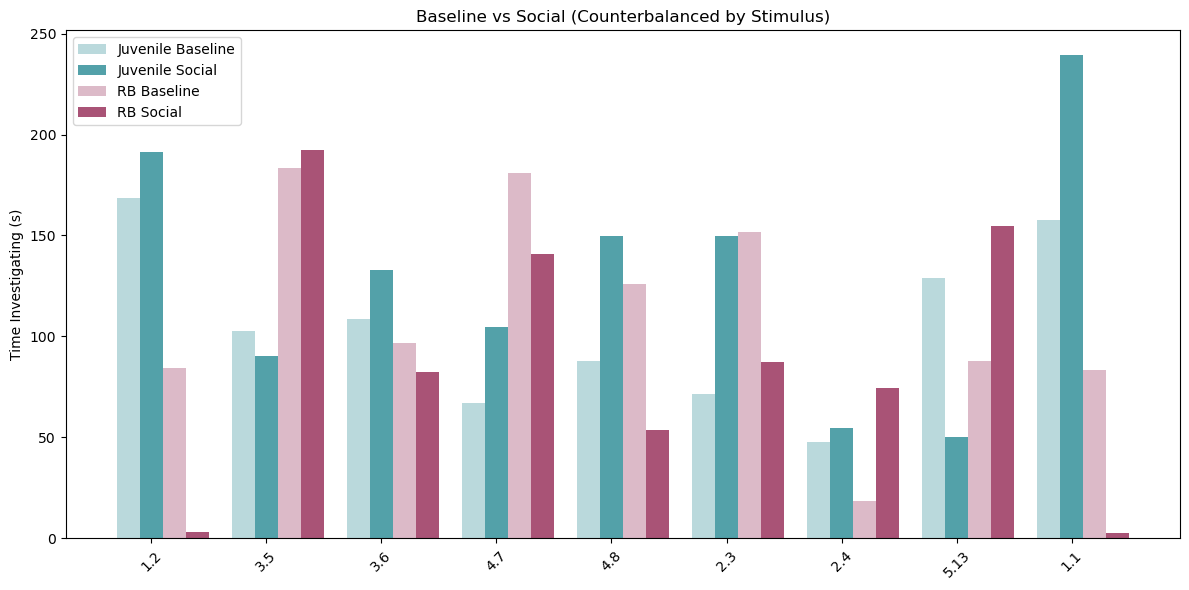

In [37]:
import matplotlib.pyplot as plt
import numpy as np

animals = df_social["Animal"].astype(str)
x = np.arange(len(animals))
bar_width = 0.2

# Define colors
pos_color = custom_palette['Positive']
neg_color = custom_palette['Negative']

plt.figure(figsize=(12,6))

# Juvenile (Positive valence): baseline vs social
plt.bar(x - bar_width, df_social["Juvenile_Baseline"], width=bar_width,
        label="Juvenile Baseline", color=pos_color, alpha=0.4)   # lighter
plt.bar(x, df_social["Juvenile ROI : time investigating (s)"], width=bar_width,
        label="Juvenile Social", color=pos_color, alpha=1.0)     # solid

# Retired Breeder (Negative valence): baseline vs social
plt.bar(x + bar_width, df_social["RB_Baseline"], width=bar_width,
        label="RB Baseline", color=neg_color, alpha=0.4)         # lighter
plt.bar(x + 2*bar_width, df_social["Retired breeder ROI : time investigating (s)"], width=bar_width,
        label="RB Social", color=neg_color, alpha=1.0)           # solid

plt.xticks(x, animals, rotation=45)
plt.ylabel("Time Investigating (s)")
plt.title("Baseline vs Social (Counterbalanced by Stimulus)")
plt.legend()
plt.tight_layout()
plt.show()


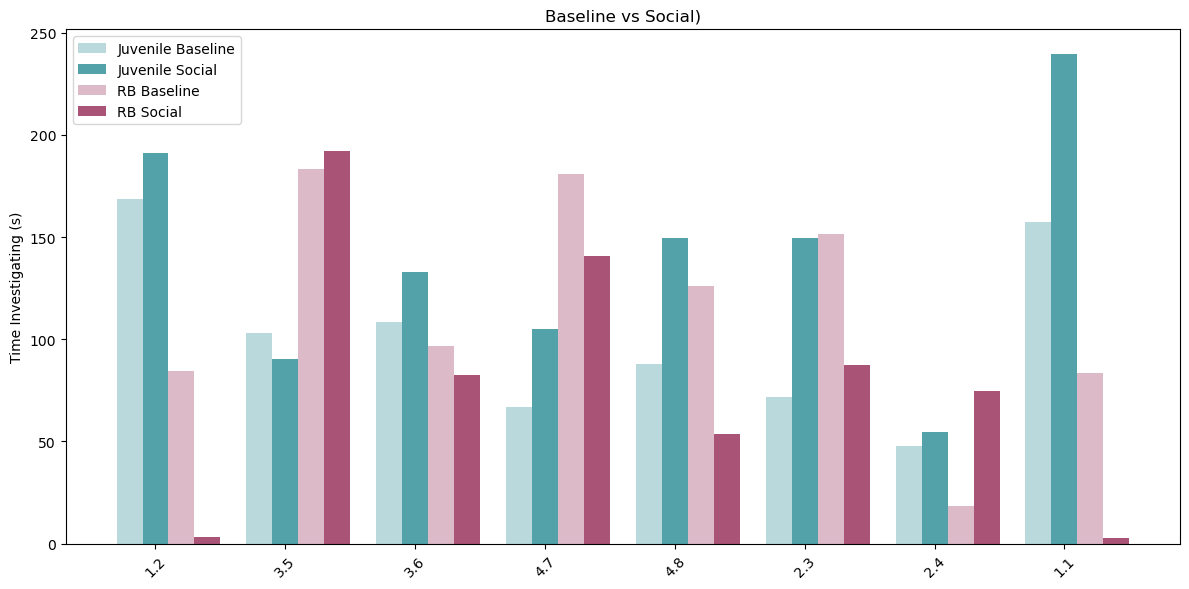

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Exclude subject 5.13
df_plot = df_social[df_social["Animal"].astype(str) != "5.13"].copy()

animals = df_plot["Animal"].astype(str)
x = np.arange(len(animals))
bar_width = 0.2

# Define colors
pos_color = custom_palette['Positive']
neg_color = custom_palette['Negative']

plt.figure(figsize=(12,6))

# Juvenile (Positive valence): baseline vs social
plt.bar(x - bar_width, df_plot["Juvenile_Baseline"], width=bar_width,
        label="Juvenile Baseline", color=pos_color, alpha=0.4)
plt.bar(x, df_plot["Juvenile ROI : time investigating (s)"], width=bar_width,
        label="Juvenile Social", color=pos_color, alpha=1.0)

# Retired Breeder (Negative valence): baseline vs social
plt.bar(x + bar_width, df_plot["RB_Baseline"], width=bar_width,
        label="RB Baseline", color=neg_color, alpha=0.4)
plt.bar(x + 2*bar_width, df_plot["Retired breeder ROI : time investigating (s)"], width=bar_width,
        label="RB Social", color=neg_color, alpha=1.0)

plt.xticks(x, animals, rotation=45)
plt.ylabel("Time Investigating (s)")
plt.title("Baseline vs Social)")
plt.legend()
plt.tight_layout()
plt.show()
